In [60]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments, scale_filter
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

from scipy.signal import windows

import itertools

D = 1

N = 10000
L = 5.*np.pi

N_f = 4*N
L_f = 4*L

grid_dims = [N for _ in range(D)]
grid_dims_f = [N_f for _ in range(D)]

phys_dims = [L for _ in range(D)]
phys_dims_f = [L_f for _ in range(D)]

twopi = 2.*np.pi

dk_f = twopi/L_f
dk = twopi/L

dx_f = L_f/N_f
dx = L/N

BREAK1 = 30 * dk_f
BREAK2 = 2000 * dk_f


In [61]:
f_f = fbm.create_fbm([N_f for _ in range(D)], phys_dims_f, (-5./3., ), gfunc='pow_exp', func_kwargs={'breaks': (BREAK1, BREAK2)})
#f_f = fbm.create_fbm([N_f for _ in range(D)], phys_dims_f, (-5./3.,), gfunc='pure_pow')
f = f_f[N_f//2-N//2:N_f//2+N//2]
f = f - np.mean(f)
f_p = windows.tukey(N, 0.1) * f

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:114: RuntimeWarning: divide by zero encountered in power
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:114: RuntimeWarning: divide by zero encountered in true_divide
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:114: RuntimeWarning: invalid value encountered in multiply
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)


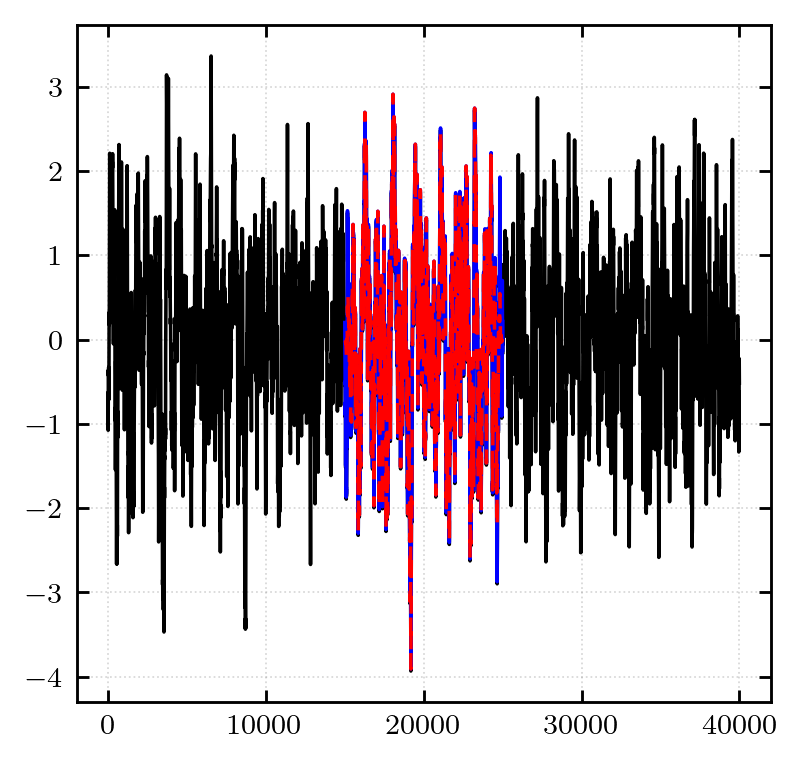

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
ax.plot(f_f, linewidth=1., color='black')
ax.plot(np.arange(N_f//2-N//2, N_f//2+N//2), f, linewidth=1., color='blue')
ax.plot(np.arange(N_f//2-N//2, N_f//2+N//2), f_p, linewidth=1., color='red', linestyle=(0,(5,5)))
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

Text(0.5, 0, 'Wavenumber, $k$')

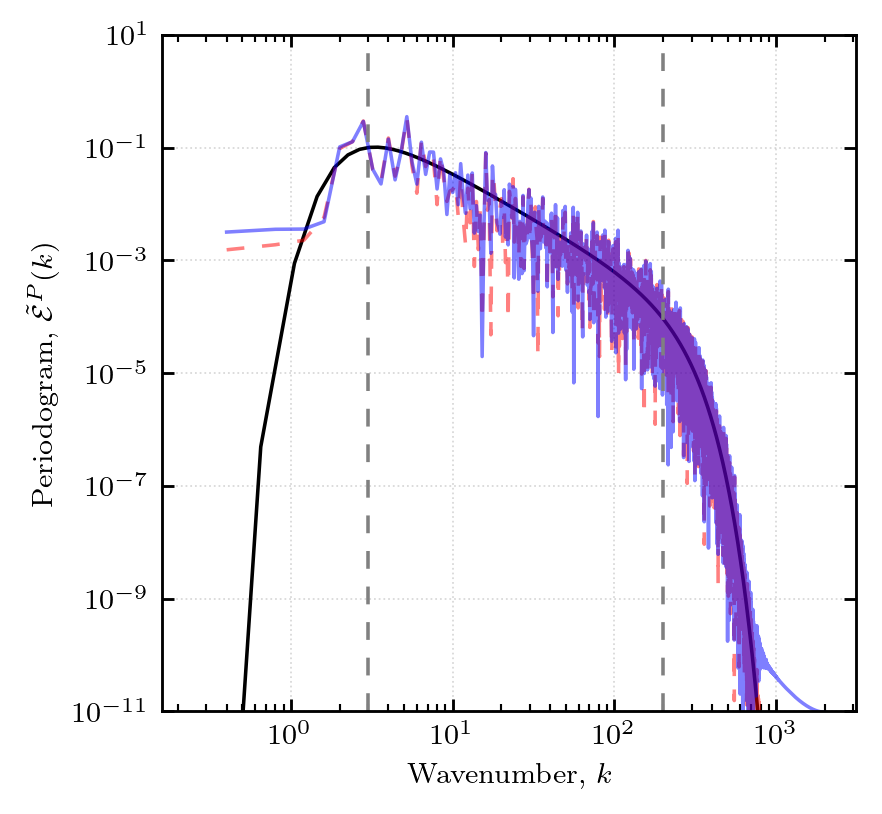

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

kD_f, fekD_f = per_spectra.modal_spectrum(f_f, phys_dims=phys_dims_f)
fekD_f = fekD_f * (dk_f/twopi)**D
k_f, fek_f, _ = spectra_base.spectrum_integrate(kD_f, fekD_f, spec_type='omni', lenn=phys_dims_f, num_bins=N//2)
ax.loglog(k_f, fek_f, color='black', linewidth=1.)

kD_p, fekD_p = per_spectra.modal_spectrum(f_p, phys_dims=phys_dims)
fekD_p = fekD_p * (dk/twopi)**D
k_p, fek_p, _ = spectra_base.spectrum_integrate(kD_p, fekD_p, spec_type='omni', lenn=phys_dims, num_bins=N//2)
ax.loglog(k_p, fek_p, color='red', linewidth=1., linestyle=(0,(5,5)), alpha=0.5)

kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
k, fek, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims, num_bins=N//2)
ax.loglog(k, fek, color='blue', linewidth=1., alpha=0.5)

ax.axvline(BREAK1, linewidth=1., color='gray', linestyle=(0,(5,5)))
ax.axvline(BREAK2, linewidth=1., color='gray', linestyle=(0,(5,5)))

ax.set_ylim((1e-11, 1e1))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'Periodogram, $\tilde{\mathcal{E}}^P(k)$')
ax.set_xlabel(r'Wavenumber, $k$')

In [64]:

def SmoothySpec(a,start=None,end=None,width=3):
   b=a.copy()
   if start is None: start = 0
   if end is None: end = len(a)
   for i in range(start,end):
      #b[i+1::][:-1] = 0.25*b[i::][:-2]+0.5*b[i+1::][:-1]+0.25*b[i::][2:]
      b[i+1:-1] = 0.25*b[i:-2] + 0.5*b[i+1:-1] + 0.25*b[i+2:]
   return b


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


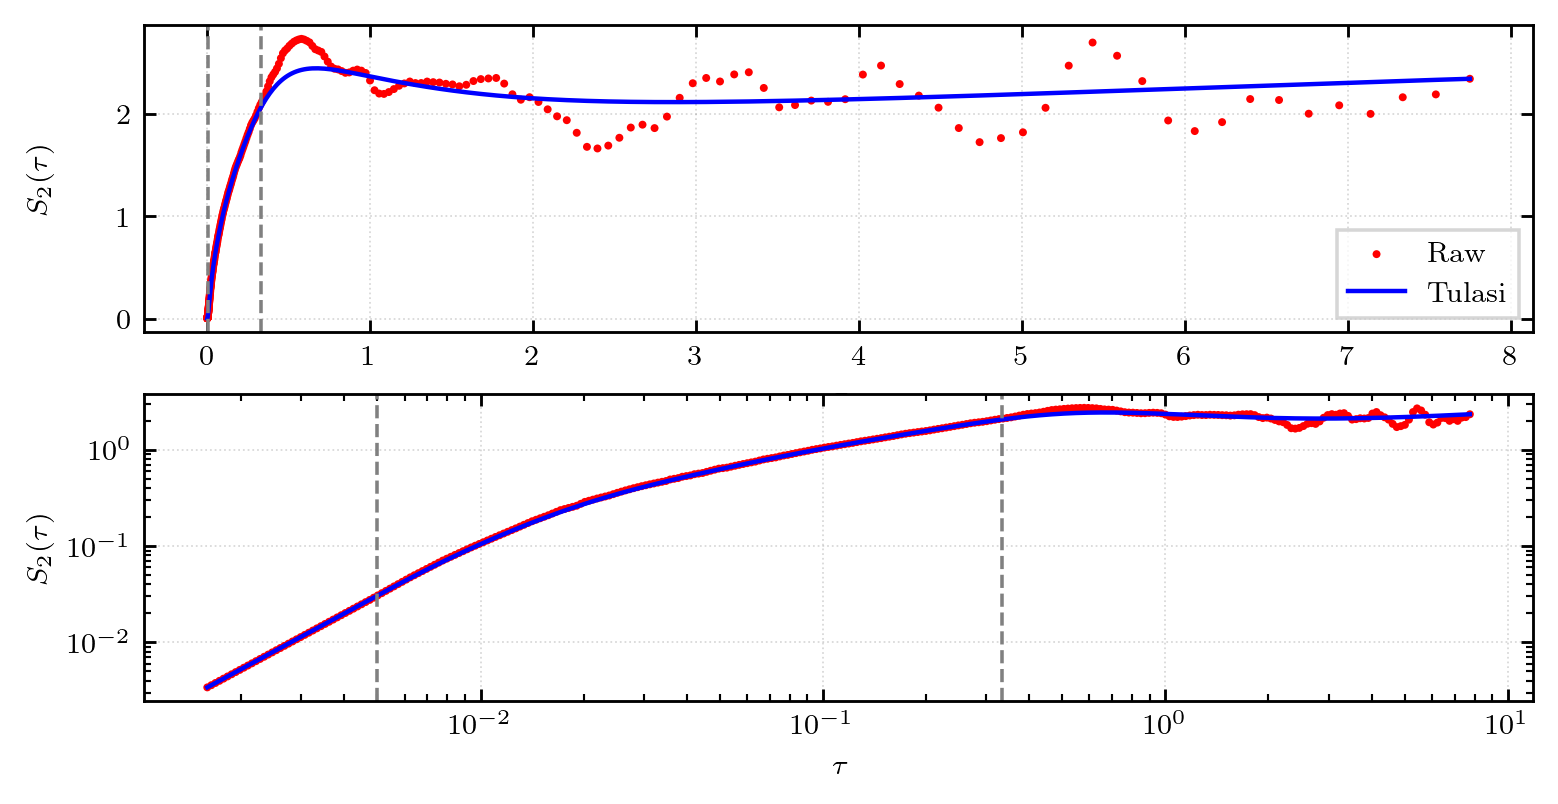

In [65]:

fig, ax = plt.subplots(2, 1, figsize=(3.5*2., 3.5), dpi=256)

lv_p = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
sf_p = strfn.process_lags(f_p, f_p, lv_p, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=True)[0]
lvm_p = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx
l_p, sf2_p, w_p = statistics_base.bin_data(lvm_p, sf_p, bin_func=np.nanmean, cut_excess=True, nan_small=False,
                                           min_bin=dx, max_bin=L/2., bin_loc='center', log_space=True, num_bins=N//32)


l_pr = l_p[np.isfinite(sf2_p)]
sf2_pr = sf2_p[np.isfinite(sf2_p)]

sf2_pi = strfn_spectra.interpolate(l_pr, sf2_pr, l_p)

for axx in ax:
    axx.scatter(l_p, sf2_pi, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='none', label='Raw')


sf2_s1 = np.exp(SmoothySpec(np.log(sf2_pi)))
NN = 8
for _i in range(NN):
    sf2_s1 = np.exp(SmoothySpec(np.log(sf2_s1), start=_i*N//NN))
for _ in range(5):
    sf2_s1 = np.exp(SmoothySpec(np.log(sf2_s1), end=12))
#for _ in range(50):
#   sf2_s1 = np.exp(SmoothySpec(np.log(sf2_s1), start=np.min(np.where(l_p > 1./BREAK)[0])))
for axx in ax:
    axx.plot(l_p, sf2_s1, color='blue', linewidth=1.25, linestyle='-', label='Tulasi')


for axx in ax:
    axx.axvline(1./BREAK1, linewidth=1., color='gray', linestyle='--')
    axx.axvline(1./BREAK2, linewidth=1., color='gray', linestyle='--')

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    axx.set_ylabel(r'$S_2(\tau)$')
    axx.set_xlabel(r'$\tau$')

ax[0].legend(fancybox=False)
ax[1].set_yscale('log')
ax[1].set_xscale('log')

fig.align_ylabels()


/tmp/ipykernel_107706/1617177037.py:26: RuntimeWarning: invalid value encountered in log
  est_alpha = np.gradient(np.log(sfek_p), np.log(lk_p))


2*sqrt(pi)*gamma(3/2 - alpha/2)/(2**alpha*gamma(alpha/2))

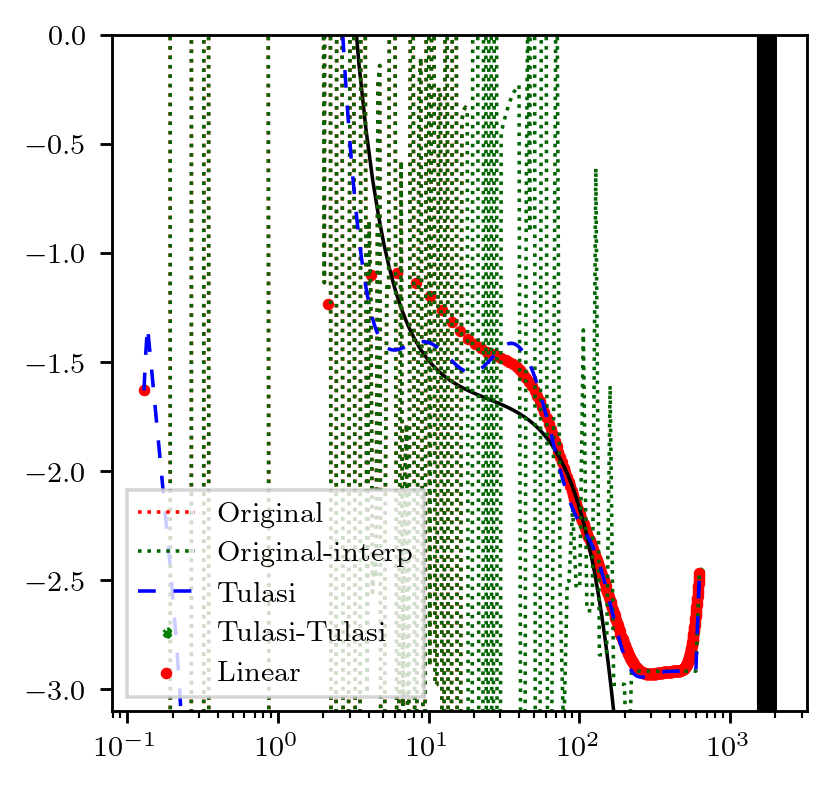

In [66]:

def omni_spectrum(ell, sf2, phys_dims, grid_dims, a=1., b=1.):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    return kk[::-1], fek[::-1]

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

true_alpha = np.gradient(np.log(fek_f), np.log(k_f))
ax.plot(k_f, true_alpha, linewidth=1., linestyle='-', color='black')

lk_o, sfek_o = omni_spectrum(l_p, sf2_pi, phys_dims, grid_dims)

smooth_specs = [sf2_p, sf2_pi, sf2_s1]
e_specs = []
e_alphas = []
for sp in smooth_specs:
    lk_p, sfek_p = omni_spectrum(l_p, sp, phys_dims, grid_dims)
    est_alpha = np.gradient(np.log(sfek_p), np.log(lk_p))
    #est_alpha = (lk_p / sfek_p) * np.gradient(sp, lk_p)
    e_specs.append((lk_p, sfek_p))
    e_alphas.append((est_alpha))

ax.plot(e_specs[0][0], e_alphas[0], linewidth=1., linestyle=':', color='red', label='Original')
ax.plot(e_specs[1][0], e_alphas[1], linewidth=1., linestyle=':', color='darkgreen', label='Original-interp')
ax.plot(e_specs[2][0], e_alphas[2], linewidth=1., linestyle=(0,(5,5)), color='blue', label='Tulasi')
#ax.plot(e_specs[2][0], e_alphas[2], linewidth=1., linestyle='--', color='darkred', label='Median')
#ax.plot(e_specs[3][0], e_alphas[3], linewidth=1., linestyle='-.', color='green', label='Median+Tulasi')


e_alphas12 = SmoothySpec(e_alphas[2])
for _ in range(25):
    e_alphas12 = SmoothySpec(e_alphas12)
ax.scatter(e_specs[1][0], e_alphas12, linewidth=1., linestyle=(0,(5,5)), color='green', label='Tulasi-Tulasi', s=5., marker='X')


from scipy.interpolate import interp1d

def interpp(x, y, xi):
    ff = interp1d(x, y, kind='linear', fill_value='extrapolate')
    ynew = ff(xi)
    return ynew

linear_x = np.linspace(np.min(lk_p), np.max(lk_p), len(lk_p))
elph_linear = interpp(lk_p, e_alphas[2], linear_x)
e_alphas12_linear = SmoothySpec(elph_linear)
for _ in range(5):
   e_alphas12_linear = SmoothySpec(e_alphas12_linear)
ax.scatter(linear_x, e_alphas12_linear, linewidth=1., color='red', label='Linear', s=5., marker='o')



# f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')
#     fek_new = f_int(np.log10(k_interp))
#     return 10**fek_new

# TODO: The problem is, this data is not evenly sampled

#from scipy.signal import savgol_filter
#est_alpha2 = (lk_p / sfek_p) * non_uniform_savgol(lk_p, sfek_p, 151, 15)#savgol_filter(np.log(sfek_p), 150, 10, deriv=1, delta=np.log(np.gradient(lk_p)))
#est_alpha2 = (lk_p / sfek_p) * savgol_filter(sfek_p, 150, 10, deriv=1, delta=dk)

# est_alpha2 = savgol_filter(np.log(sfek_o), len(sfek_o)//10, 2, deriv=1, delta=np.gradient(np.log(lk_o))[0])
# ax.plot(lk_p, est_alpha2, linewidth=1., linestyle=':', color='orange', label='Savitzky-Golay')

#ax.plot(lk_p, est_alpha, linewidth=1., linestyle=(0,(5,5)), color='blue')
#ax.plot(lk_p, est_alpha2, linewidth=1., linestyle=':', color='green')

#e_alphas13 = savgol_filter(e_alphas[1], len(e_alphas[1])//2, 3, delta=np.log(np.gradient(e_specs[1][0])))
#ax.plot(e_specs[1][0], e_alphas[1], linewidth=1., linestyle='-.', color='black', label='Tulasi-Savgol')

import sympy as sp

sp_alpha = sp.symbols('alpha', positive=True, real=True)
spec_bias = sp.S(2)*sp.S(2)**(-sp_alpha) * sp.sqrt(sp.pi) * (sp.gamma((sp.S(3) - sp_alpha) / sp.S(2))/sp.gamma(sp_alpha/sp.S(2)))
display(spec_bias)

bias_factor = []
for _a in e_alphas[2]:
    est_alpha[est_alpha > -1.1] = -1.1
    est_alpha[est_alpha < -2.9] = -2.9
    bias_factor.append(np.float64(spec_bias.subs({sp_alpha: -_a}).evalf()))
bias_factor = np.array(bias_factor)

#ax.plot(lk_p, est_alpha, linewidth=1., linestyle=(0,(5,5)), color='gray')

ax.set_xscale('log')
ax.set_ylim((-3.1, 0.))

ax.legend(fancybox=False, loc='lower left')


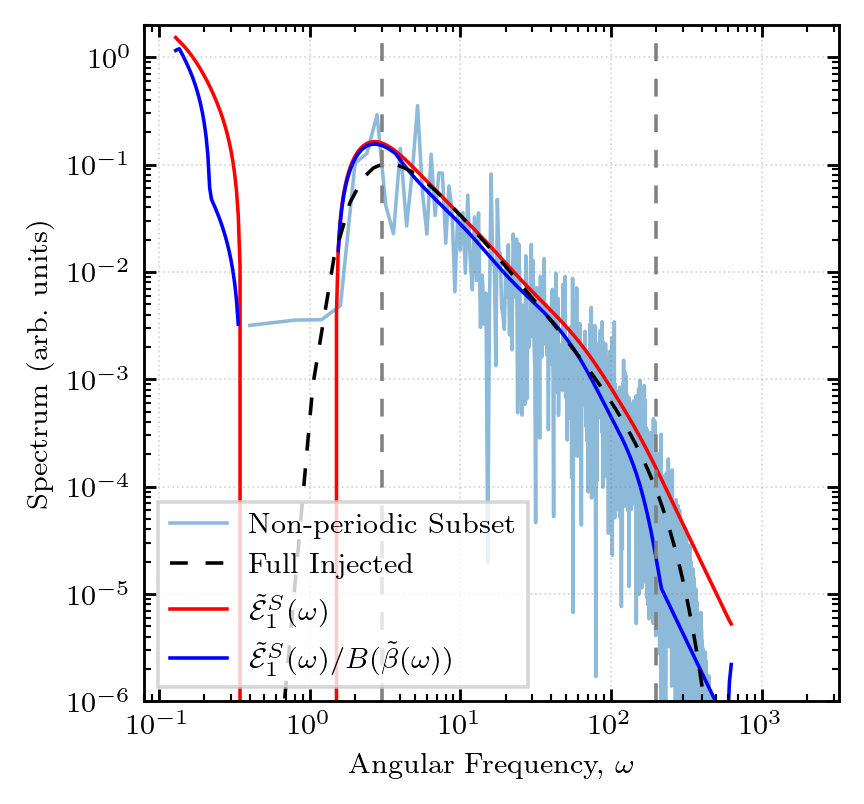

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.loglog(k, fek, linewidth=1., alpha=0.5, zorder=0, label='Non-periodic Subset')

ax.loglog(k_f, fek_f, linewidth=1., alpha=1., color='black', zorder=2, linestyle=(0,(5,5)), label='Full Injected')

ax.loglog(lk_p, sfek_p, linewidth=1., color='red', zorder=1, label=r'$\tilde{\mathcal{E}}^S_1(\omega)$')
ax.loglog(lk_p, sfek_p/bias_factor, linewidth=1., color='blue', zorder=1, label=r'$\tilde{\mathcal{E}}^S_1(\omega)/B(\tilde{\beta}(\omega))$')

ax.axvline(BREAK1, color='gray', linestyle=(0,(5,5)), linewidth=1.)
ax.axvline(BREAK2, color='gray', linestyle=(0,(5,5)), linewidth=1.)
ax.set_ylim((1e-6, 2e0))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.legend(frameon=True, fancybox=False)

ax.set_ylabel(r'Spectrum (arb. units)')
ax.set_xlabel(r'Angular Frequency, $\omega$')

fig.savefig('plots/realistic_example_1d.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/realistic_example_1d.png', transparent=True, bbox_inches='tight', pad_inches=0)


/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/strfn_spectra.py:32: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')


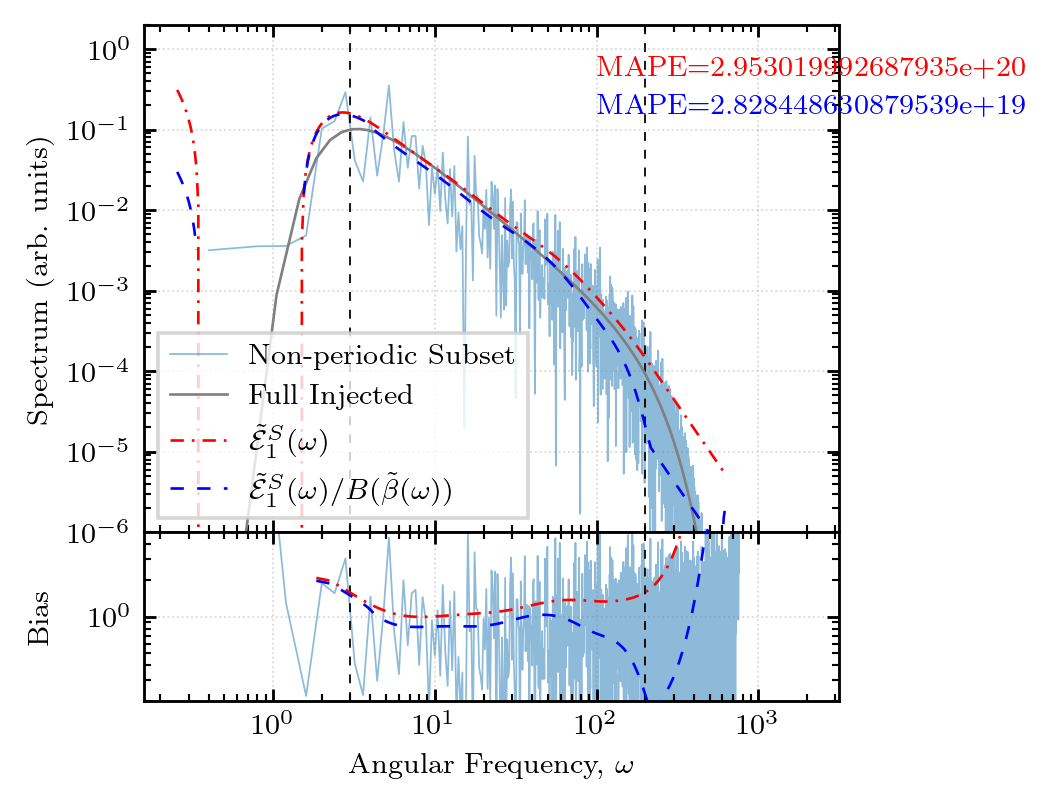

In [68]:

fig = plt.figure(1, dpi=256, figsize=(3.5, 3.5))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], figure=fig, hspace=0., wspace=0.05)

ax = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]


kmin = np.nanmin(k_f)
sfek_pr = sfek_p[lk_p >= kmin]
bias_factorr = bias_factor[lk_p >= kmin]
lk_pr = lk_p[lk_p >= kmin]

ax[0].loglog(k, fek, linewidth=0.5, alpha=0.5, zorder=0, label='Non-periodic Subset')
ax[0].loglog(k_f, fek_f, linewidth=0.75, alpha=1., color='gray', zorder=2, linestyle='-', label='Full Injected')
ax[0].loglog(lk_pr, sfek_pr, linewidth=0.75, linestyle=(0,(5,3,1,3)), color='red', zorder=3, label=r'$\tilde{\mathcal{E}}^S_1(\omega)$')
ax[0].loglog(lk_pr, sfek_pr/bias_factorr, linewidth=0.75, linestyle=(0,(5,5)), color='blue', zorder=4, label=r'$\tilde{\mathcal{E}}^S_1(\omega)/B(\tilde{\beta}(\omega))$')

ksame = k_f[k_f <= np.max(lk_pr)]
ssame = fek_f[k_f <= np.max(lk_pr)]

#kbad = k[k <= np.max(lk_pr)]
#sbad = fek[k <= np.max(lk_pr)]

good_spec = strfn_spectra.interpolate(k_f, fek_f, k)
i_spec = strfn_spectra.interpolate(lk_pr, sfek_pr, ksame)
b_spec = strfn_spectra.interpolate(lk_pr, sfek_pr/bias_factorr, ksame)

ax[1].loglog(k, fek/good_spec, linewidth=0.5, alpha=0.5, zorder=0, label='Non-periodic Subset')
ax[1].loglog(ksame, i_spec/ssame, linewidth=0.75, linestyle=(0,(5,3,1,3)), color='red', zorder=2, label=r'$\tilde{\mathcal{E}}^S_1(\omega)$')
ax[1].loglog(ksame, b_spec/ssame, linewidth=0.75, linestyle=(0,(5,5)), color='blue', zorder=3, label=r'$\tilde{\mathcal{E}}^S_1(\omega)/B(\tilde{\beta}(\omega))$')


def MAPE(At, Ft):
    return np.nanmean(np.abs((At - Ft)/At))
props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
ax[0].text(1e2, 0.9, r'MAPE=%s' % MAPE(ssame, i_spec).round(decimals=3), color='red', transform=ax[0].get_xaxis_transform(), bbox=props)
ax[0].text(1e2, 0.825, r'MAPE=%s' % MAPE(ssame, b_spec).round(decimals=3), color='blue', transform=ax[0].get_xaxis_transform(), bbox=props)


ax[0].set_ylim((1e-6, 2e0))

for axx in ax:
    axx.axvline(BREAK1, color='black', linestyle=(0,(5,5)), linewidth=0.5, zorder=1)
    axx.axvline(BREAK2, color='black', linestyle=(0,(5,5)), linewidth=0.5, zorder=1)
    axx.set_yscale('log')
    axx.set_xscale('log')
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[1].set_xlim(ax[0].get_xlim())

ax[0].set_xticklabels([])

ax[0].legend(frameon=True, fancybox=False)

ax[1].set_ylim((2e-1, 5e0))

ax[0].set_ylabel(r'Spectrum (arb. units)')
ax[1].set_ylabel(r'Bias')
ax[1].set_xlabel(r'Angular Frequency, $\omega$')

fig.align_ylabels()

fig.savefig('plots/realistic_fbm_1d_2.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/realistic_fbm_1d_2.png', transparent=True, bbox_inches='tight', pad_inches=0)
 

In [69]:
## Can we compute bias factor for 2D and 3D
## - This will determine how much we want to talk about debiasing

## >> APJ
## Bare min. number of figures

## MAPE or BIAS or SOMETHING...
## QUANTIFYING DIFFERENCES 

## Geophys
## Oceanography
## Atmospheric
## Space/astro

## Supplementary material


In [70]:
def non_uniform_savgol(x, y, window, polynom):
    """
    Applies a Savitzky-Golay filter to y with non-uniform spacing
    as defined in x

    This is based on https://dsp.stackexchange.com/questions/1676/savitzky-golay-smoothing-filter-for-not-equally-spaced-data
    The borders are interpolated like scipy.signal.savgol_filter would do

    Parameters
    ----------
    x : array_like
        List of floats representing the x values of the data
    y : array_like
        List of floats representing the y values. Must have same length
        as x
    window : int (odd)
        Window length of datapoints. Must be odd and smaller than x
    polynom : int
        The order of polynom used. Must be smaller than the window size

    Returns
    -------
    np.array of float
        The smoothed y values
    """
    if len(x) != len(y):
        raise ValueError('"x" and "y" must be of the same size')

    if len(x) < window:
        raise ValueError('The data size must be larger than the window size')

    if type(window) is not int:
        raise TypeError('"window" must be an integer')

    if window % 2 == 0:
        raise ValueError('The "window" must be an odd integer')

    if type(polynom) is not int:
        raise TypeError('"polynom" must be an integer')

    if polynom >= window:
        raise ValueError('"polynom" must be less than "window"')

    half_window = window // 2
    polynom += 1

    # Initialize variables
    A = np.empty((window, polynom))     # Matrix
    tA = np.empty((polynom, window))    # Transposed matrix
    t = np.empty(window)                # Local x variables
    y_smoothed = np.full(len(y), np.nan)

    # Start smoothing
    for i in range(half_window, len(x) - half_window, 1):
        # Center a window of x values on x[i]
        for j in range(0, window, 1):
            t[j] = x[i + j - half_window] - x[i]

        # Create the initial matrix A and its transposed form tA
        for j in range(0, window, 1):
            r = 1.0
            for k in range(0, polynom, 1):
                A[j, k] = r
                tA[k, j] = r
                r *= t[j]

        # Multiply the two matrices
        tAA = np.matmul(tA, A)

        # Invert the product of the matrices
        tAA = np.linalg.inv(tAA)

        # Calculate the pseudoinverse of the design matrix
        coeffs = np.matmul(tAA, tA)

        # Calculate c0 which is also the y value for y[i]
        y_smoothed[i] = 0
        for j in range(0, window, 1):
            y_smoothed[i] += coeffs[0, j] * y[i + j - half_window]

        # If at the end or beginning, store all coefficients for the polynom
        if i == half_window:
            first_coeffs = np.zeros(polynom)
            for j in range(0, window, 1):
                for k in range(polynom):
                    first_coeffs[k] += coeffs[k, j] * y[j]
        elif i == len(x) - half_window - 1:
            last_coeffs = np.zeros(polynom)
            for j in range(0, window, 1):
                for k in range(polynom):
                    last_coeffs[k] += coeffs[k, j] * y[len(y) - window + j]

    # Interpolate the result at the left border
    for i in range(0, half_window, 1):
        y_smoothed[i] = 0
        x_i = 1
        for j in range(0, polynom, 1):
            y_smoothed[i] += first_coeffs[j] * x_i
            x_i *= x[i] - x[half_window]

    # Interpolate the result at the right border
    for i in range(len(x) - half_window, len(x), 1):
        y_smoothed[i] = 0
        x_i = 1
        for j in range(0, polynom, 1):
            y_smoothed[i] += last_coeffs[j] * x_i
            x_i *= x[i] - x[-half_window - 1]

    return y_smoothed